# Bilancio Idrico del Mais in Pianura Padana — Modello FAO-56 Penman-Monteith

## Executive Summary

Questo notebook permette di calcolare quotidianamente il fabbisogno idrico di una coltura 
di mais basato su dati meteorologici reali. Il metodo si basa sul modello standard mondiale 
FAO-56 Penman-Monteith e produce un valore concreto in mm/giorno, utilizzabile direttamente 
per decisioni di irrigazione. L'implementazione è stata validata sull'intera stagione contro 
l'ET0 FAO-56 calcolato indipendentemente da Open-Meteo (errore medio assoluto 0.12 mm/giorno, 
correlazione 0.993).

Il picco di domanda idrica reale della coltura (ETc) è stato registrato il 25 luglio 2024, 
con 6.95 mm/giorno — un valore superiore al picco meteorologico assoluto della stagione 
(6.06 mm/giorno, il 30 luglio), perché il 25 luglio la coltura è appena entrata nella fase 
finale del ciclo con un Kc ancora prossimo al massimo (1.18), in pieno riempimento della 
granella. Questo dimostra il valore aggiunto del modello rispetto a una semplice lettura dei 
dati meteo: il giorno di massima domanda idrica per la coltura non è il giorno 
meteorologicamente più estremo, ma quello in cui condizioni climatiche impegnative si 
sovrappongono a una fase fenologica ad alto fabbisogno.

## Contesto e Obiettivo
L'irrigazione del mais in Pianura Padana dipende tradizionalmente da metodi a scorrimento e turni irrigui prestabiliti, che possono discostarsi significativamente dal reale fabbisogno idrico della coltura in un dato momento. Questo scarto comporta un costo concreto: spreco d'acqua se si irriga in eccesso, perdita di resa se si irriga in difetto — un rischio che si amplifica nelle fasi critiche di fioritura e riempimento della granella. 
Questo notebook mira a produrre una stima giornaliera del fabbisogno idrico del mais, basata su dati meteorologici reali e sul modello standard internazionale FAO-56, per supportare decisioni di irrigazione guidate dai dati anziché dal solo calendario.

## Metodologia
Come primo passo è stato estratto un dataset meteorologico giornaliero (25 aprile – 25 agosto 2024, area di Cremona, Pianura Padana) dal servizio Open-Meteo, verificato privo di valori mancanti. Da questi dati sono stati calcolati i componenti necessari per stimare l'evapotraspirazione teorica (ET0), applicando il modello standard internazionale FAO-56 Penman-Monteith. Dall'ET0 è stata poi ricavata l'evapotraspirazione reale della coltura (ETc), integrando il coefficiente colturale (Kc) corrispondente allo stadio fenologico del mais nel corso della stagione.

**Validazione.** L'ET0 calcolato è confrontato con l'ET0 FAO-56 fornito direttamente da 
Open-Meteo (variabile `et0_fao_evapotranspiration`), calcolato indipendentemente a partire 
da dati orari. Il confronto verifica l'implementazione su tutti i 123 giorni della stagione, 
inclusi i valori estremi, e non solo sulla media.

Le semplificazioni adottate dal modello sono discusse nella sezione *Limitazioni note*.

In [1]:
import requests
import pandas as pd

# Coordinate indicative: Pianura Padana, zona Cremona (area maidicola storica)
LATITUDINE = 45.13
LONGITUDINE = 10.02

# Stagione di crescita del mais: da fine aprile a fine agosto 2024
DATA_INIZIO = "2024-04-25"
DATA_FINE = "2024-08-25"

url = "https://archive-api.open-meteo.com/v1/archive"
parametri = {
    "latitude": LATITUDINE,
    "longitude": LONGITUDINE,
    "start_date": DATA_INIZIO,
    "end_date": DATA_FINE,
    "daily": [
        "temperature_2m_max",
        "temperature_2m_min",
        "temperature_2m_mean",
        "relative_humidity_2m_mean",
        "shortwave_radiation_sum",
        "precipitation_sum",
        "et0_fao_evapotranspiration",  # ET0 di riferimento calcolato da Open-Meteo, per validazione
    ],
    "hourly": "wind_speed_10m",   # vento orario: serve per calcolare la MEDIA giornaliera
    "wind_speed_unit": "ms",      # il default di Open-Meteo è km/h; FAO-56 richiede m/s
    "timezone": "Europe/Rome",
}

risposta = requests.get(url, params=parametri)
risposta.raise_for_status()
dati_grezzi = risposta.json()

# Dati giornalieri
df_meteo = pd.DataFrame(dati_grezzi["daily"])
df_meteo["time"] = pd.to_datetime(df_meteo["time"])
df_meteo = df_meteo.set_index("time")
df_meteo = df_meteo.rename(columns={"et0_fao_evapotranspiration": "et0_openmeteo"})

# Vento: media giornaliera dai dati orari (FAO-56 Eq. 6 usa la media, non il massimo)
df_vento_orario = pd.DataFrame(dati_grezzi["hourly"])
df_vento_orario["time"] = pd.to_datetime(df_vento_orario["time"])
df_meteo["wind_speed_10m_mean"] = (
    df_vento_orario.set_index("time")["wind_speed_10m"].resample("D").mean()
)

print(df_meteo.shape)
print(f"Ore di vento scaricate: {len(df_vento_orario)} (attese: 123 × 24 = 2952)")
df_meteo["wind_speed_10m_mean"].describe()

(123, 8)
Ore di vento scaricate: 2952 (attese: 123 × 24 = 2952)


count    123.000000
mean       1.941423
std        0.660436
min        0.767500
25%        1.527292
50%        1.770833
75%        2.224167
max        5.816250
Name: wind_speed_10m_mean, dtype: float64

**Vento.** Open-Meteo fornisce il vento a 10 m di altezza. Il valore giornaliero è ottenuto 
come media dei 24 valori orari, richiesti in m/s: l'equazione FAO-56 è calibrata sulla 
velocità media giornaliera, e l'uso del massimo giornaliero sovrastimerebbe sistematicamente 
il termine aerodinamico. La media è poi convertita all'altezza di riferimento di 2 m con il 
profilo logaritmico del vento (FAO-56, Eq. 47).

In [2]:
#Controlla se ci sono valori mancanti
df_meteo.isna().sum()

temperature_2m_max           0
temperature_2m_min           0
temperature_2m_mean          0
relative_humidity_2m_mean    0
shortwave_radiation_sum      0
precipitation_sum            0
et0_openmeteo                0
wind_speed_10m_mean          0
dtype: int64

In [3]:
import numpy as np

def pressione_vapore_saturo(temperatura_celsius):
    """
    Calcola la pressione di vapore saturo (kPa) - Equazione FAO-56 (11).
    Formula di Tetens/Magnus-Tetens.
    """
    return 0.6108 * np.exp((17.27 * temperatura_celsius) / (temperatura_celsius + 237.3))

# es si calcola sulla media tra Tmax e Tmin (non sulla media giornaliera diretta,
# perché la curva es(T) è esponenziale e non lineare -> media dei due estremi è più accurata)
df_meteo["es"] = (
    pressione_vapore_saturo(df_meteo["temperature_2m_max"]) +
    pressione_vapore_saturo(df_meteo["temperature_2m_min"])
) / 2

# ea si stima dall'umidità relativa media applicata a es medio
df_meteo["ea"] = df_meteo["es"] * (df_meteo["relative_humidity_2m_mean"] / 100)

# Deficit di pressione di vapore (VPD): la "sete" dell'aria, motore del termine aerodinamico
df_meteo["vpd"] = df_meteo["es"] - df_meteo["ea"]

df_meteo[["es", "ea", "vpd"]].describe()

,es,ea,vpd
count,123.000000,123.000000,123.000000
mean,2.899261,2.107308,0.791953
std,0.801624,0.448808,0.437770
min,1.259498,0.944623,0.159925
25%,2.216548,1.725007,0.441081
50%,2.881764,2.193372,0.669450
75%,3.648928,2.478492,1.115456
max,4.277936,2.983868,1.887080


In [4]:
def pendenza_curva_vapore(temperatura_celsius):
    """
    Calcola Delta (kPa/°C) - Equazione FAO-56 (13).
    Deriva dalla stessa curva di pressione di vapore saturo usata sopra.
    """
    es = pressione_vapore_saturo(temperatura_celsius)
    return (4098 * es) / ((temperatura_celsius + 237.3) ** 2)

def costante_psicrometrica(altitudine_metri):
    """
    Calcola gamma (kPa/°C) - Equazioni FAO-56 (7) e (8).
    """
    # Pressione atmosferica in funzione dell'altitudine (formula barometrica semplificata FAO)
    pressione_atmosferica = 101.3 * ((293 - 0.0065 * altitudine_metri) / 293) ** 5.26
    return 0.000665 * pressione_atmosferica

# Delta va calcolato sulla temperatura media giornaliera
df_meteo["delta"] = pendenza_curva_vapore(df_meteo["temperature_2m_mean"])

# Gamma è (quasi) costante nel tempo per un dato sito: la zona di Cremona è a ~45m s.l.m.
ALTITUDINE_SITO = 45
gamma = costante_psicrometrica(ALTITUDINE_SITO)

print(f"Gamma per il sito (costante): {gamma:.5f} kPa/°C")
df_meteo[["delta"]].describe()

Gamma per il sito (costante): 0.06701 kPa/°C


,delta
count,123.000000
mean,0.166811
std,0.041117
min,0.080839
25%,0.131206
50%,0.167246
75%,0.204921
max,0.239744


In [5]:
# Verifica di coerenza: Δ cresce con la temperatura (curva esponenziale),
# quindi in luglio ET0 è più sensibile a variazioni di temperatura che in aprile
for descrizione, temperatura in [("aprile, 15 °C", 15), ("luglio, 28 °C", 28)]:
    print(f"Δ {descrizione}: {pendenza_curva_vapore(temperatura):.3f} kPa/°C")

Δ aprile, 15 °C: 0.110 kPa/°C
Δ luglio, 28 °C: 0.220 kPa/°C


In [6]:
def radiazione_extraterrestre(giorno_anno, latitudine_gradi):
    """
    Calcola Ra (MJ/m2/giorno) - Equazione FAO-56 (21).
    Radiazione che arriverebbe al top dell'atmosfera, in assenza di essa.
    Dipende solo da geometria Terra-Sole: giorno dell'anno + latitudine.
    """
    lat_rad = np.radians(latitudine_gradi)
    
    # Distanza relativa inversa Terra-Sole (varia leggermente durante l'anno)
    dr = 1 + 0.033 * np.cos(2 * np.pi * giorno_anno / 365)
    
    # Declinazione solare (l'inclinazione del sole rispetto all'equatore in quel giorno)
    declinazione = 0.409 * np.sin(2 * np.pi * giorno_anno / 365 - 1.39)
    
    # Angolo orario del tramonto
    omega_s = np.arccos(-np.tan(lat_rad) * np.tan(declinazione))
    
    Gsc = 0.0820  # costante solare, MJ/m2/min
    Ra = (24 * 60 / np.pi) * Gsc * dr * (
        omega_s * np.sin(lat_rad) * np.sin(declinazione) +
        np.cos(lat_rad) * np.cos(declinazione) * np.sin(omega_s)
    )
    return Ra

# Serve il "giorno dell'anno" (1-365) per ogni riga
df_meteo["giorno_anno"] = df_meteo.index.dayofyear

df_meteo["ra"] = radiazione_extraterrestre(df_meteo["giorno_anno"], LATITUDINE)

df_meteo[["giorno_anno", "ra"]].describe()

,giorno_anno,ra
count,123.000000,123.000000
mean,177.000000,39.251066
std,35.651087,2.431420
min,116.000000,33.052829
25%,146.500000,37.540769
50%,177.000000,39.895461
75%,207.500000,41.400234
max,238.000000,41.911315


In [7]:
# Verifica: Ra cresce fino al solstizio d'estate (21 giugno, giorno 172) e poi cala
primo_giorno = df_meteo.index[0]
giorno_solstizio = df_meteo["giorno_anno"].sub(172).abs().idxmin()
print(f"Ra al {primo_giorno.date()} (giorno {primo_giorno.dayofyear}): {df_meteo['ra'].iloc[0]:.2f} MJ/m2/giorno")
print(f"Ra al solstizio ({giorno_solstizio.date()}): {df_meteo.loc[giorno_solstizio, 'ra']:.2f} MJ/m2/giorno")

Ra al 2024-04-25 (giorno 116): 35.71 MJ/m2/giorno
Ra al solstizio (2024-06-20): 41.91 MJ/m2/giorno


In [8]:
def radiazione_cielo_sereno(ra, altitudine_metri):
    """
    Calcola Rso (MJ/m2/giorno) - Equazione FAO-56 (37).
    Approssimazione: quanta radiazione solare arriverebbe al suolo
    in una giornata perfettamente serena, corretta per l'altitudine
    (meno atmosfera da attraversare in quota = meno radiazione assorbita).
    """
    return (0.75 + 2e-5 * altitudine_metri) * ra

df_meteo["rso"] = radiazione_cielo_sereno(df_meteo["ra"], ALTITUDINE_SITO)

# Rns: radiazione netta ad onda corta - Equazione FAO-56 (38)
# La coltura riflette una parte della radiazione (albedo, alpha=0.23 per colture verdi standard)
ALBEDO = 0.23
df_meteo["rns"] = (1 - ALBEDO) * df_meteo["shortwave_radiation_sum"]

df_meteo[["ra", "rso", "shortwave_radiation_sum", "rns"]].describe()

,ra,rso,shortwave_radiation_sum,rns
count,123.000000,123.000000,123.000000,123.000000
mean,39.251066,29.473625,21.762358,16.757015
std,2.431420,1.825753,4.259495,3.279811
min,33.052829,24.819369,6.760000,5.205200
25%,37.540769,28.189364,20.130000,15.500100
50%,39.895461,29.957502,22.550000,17.363500
75%,41.400234,31.087435,24.860000,19.142200
max,41.911315,31.471207,27.490000,21.167300


In [9]:
df_meteo["rapporto_nuvolosita"] = df_meteo["shortwave_radiation_sum"] / df_meteo["rso"]
df_meteo["rapporto_nuvolosita"].describe()

count    123.000000
mean       0.738578
std        0.138588
min        0.243654
25%        0.664326
50%        0.786138
75%        0.842965
max        0.882537
Name: rapporto_nuvolosita, dtype: float64

In [10]:
def radiazione_netta_onda_lunga(t_max_celsius, t_min_celsius, ea, rs, rso):
    """
    Calcola Rnl (MJ/m2/giorno) - Equazione FAO-56 (39).
    Perdita netta di radiazione infrarossa verso il cielo.
    """
    STEFAN_BOLTZMANN = 4.903e-9  # MJ/K^4/m2/giorno
    
    t_max_kelvin = t_max_celsius + 273.16
    t_min_kelvin = t_min_celsius + 273.16
    
    # Termine di temperatura: emissione media alla 4a potenza (Stefan-Boltzmann)
    termine_temperatura = STEFAN_BOLTZMANN * (t_max_kelvin**4 + t_min_kelvin**4) / 2
    
    # Termine di umidità: più vapore acqueo, minore la perdita netta (effetto "coperta")
    termine_umidita = 0.34 - 0.14 * np.sqrt(ea)
    
    # Termine di nuvolosità: rapporto Rs/Rso, clippato a max 1.0 per sicurezza numerica
    rapporto = np.clip(rs / rso, 0, 1)
    termine_nuvolosita = 1.35 * rapporto - 0.35
    
    return termine_temperatura * termine_umidita * termine_nuvolosita

df_meteo["rnl"] = radiazione_netta_onda_lunga(
    df_meteo["temperature_2m_max"],
    df_meteo["temperature_2m_min"],
    df_meteo["ea"],
    df_meteo["shortwave_radiation_sum"],
    df_meteo["rso"]
)

# Finalmente: la Radiazione Netta completa
df_meteo["rn"] = df_meteo["rns"] - df_meteo["rnl"]

df_meteo[["rns", "rnl", "rn"]].describe()

,rns,rnl,rn
count,123.000000,123.000000,123.000000
mean,16.757015,3.296364,13.460652
std,3.279811,0.996179,2.439900
min,5.205200,-0.123547,5.328747
25%,15.500100,2.836029,12.294402
50%,17.363500,3.540386,13.978931
75%,19.142200,4.006945,15.200426
max,21.167300,5.347311,17.204191


In [11]:
#Rnl non dovrebbe mai essere negativo
#Un valore negativo è un artefatto numerico dell'equazione empirica FAO-56, calibrata per condizioni di cielo da sereno a moderatamente nuvoloso, 
#non per giornate estremamente coperte.

giorno_critico = df_meteo["rnl"].idxmin()
print(df_meteo.loc[giorno_critico, ["shortwave_radiation_sum", "rso", "rapporto_nuvolosita", "relative_humidity_2m_mean", "rnl"]])

shortwave_radiation_sum       6.760000
rso                          27.744263
rapporto_nuvolosita           0.243654
relative_humidity_2m_mean    82.000000
rnl                          -0.123547
Name: 2024-05-01 00:00:00, dtype: float64


In [12]:
n_giorni_anomali = (df_meteo["rnl"] < 0).sum()
print(f"Giorni con Rnl negativo (limite noto FAO-56 in condizioni di cielo molto coperto): {n_giorni_anomali}")

Giorni con Rnl negativo (limite noto FAO-56 in condizioni di cielo molto coperto): 2


In [13]:
# Fattore di conversione vento 10m -> 2m (Eq. FAO-56 (47), profilo logaritmico)
# Costante per qualunque conversione 10m->2m: non dipende dai dati, solo dalla geometria dell'equazione
FATTORE_CONVERSIONE_VENTO_10M_A_2M = 4.87 / np.log(67.8 * 10 - 5.42)

def correggi_vento_a_2m(vento_10m):
    """Corregge la velocità del vento da 10m a 2m di altezza - Equazione FAO-56 (47)."""
    return vento_10m * FATTORE_CONVERSIONE_VENTO_10M_A_2M

df_meteo["u2"] = correggi_vento_a_2m(df_meteo["wind_speed_10m_mean"])
df_meteo[["wind_speed_10m_mean", "u2"]].describe()

,wind_speed_10m_mean,u2
count,123.000000,123.000000
mean,1.941423,1.452089
std,0.660436,0.493973
min,0.767500,0.574052
25%,1.527292,1.142339
50%,1.770833,1.324497
75%,2.224167,1.663568
max,5.816250,4.350270


In [14]:
def calcola_et0_penman_monteith(delta, gamma, rn, u2, temperatura_media, vpd):
    """
    Calcola ET0 (mm/giorno) - Equazione FAO-56 Penman-Monteith completa (Eq. 6).
    
    Parametri:
    - delta: pendenza curva pressione vapore (kPa/°C)
    - gamma: costante psicrometrica (kPa/°C)
    - rn: radiazione netta (MJ/m2/giorno)
    - u2: vento a 2m (m/s)
    - temperatura_media: temperatura media giornaliera (°C)
    - vpd: deficit di pressione di vapore, es - ea (kPa)
    """
    G = 0  # flusso di calore nel suolo, approssimato a zero su base giornaliera (standard FAO)
    
    numeratore = 0.408 * delta * (rn - G) + gamma * (900 / (temperatura_media + 273)) * u2 * vpd
    denominatore = delta + gamma * (1 + 0.34 * u2)
    
    return numeratore / denominatore

df_meteo["et0"] = calcola_et0_penman_monteith(
    delta=df_meteo["delta"],
    gamma=gamma,  # costante, calcolata prima
    rn=df_meteo["rn"],
    u2=df_meteo["u2"],
    temperatura_media=df_meteo["temperature_2m_mean"],
    vpd=df_meteo["vpd"]
)

df_meteo["et0"].describe()

count    123.000000
mean       4.231586
std        1.044738
min        1.464092
25%        3.521789
50%        4.372883
75%        5.038428
max        6.057570
Name: et0, dtype: float64

In [15]:
# Verifica del giorno di picco di ET0: il valore è credibile se coincide con
# temperatura alta, vento sostenuto e umidità bassa
giorno_picco = df_meteo["et0"].idxmax()
print(df_meteo.loc[giorno_picco, ["temperature_2m_max", "wind_speed_10m_mean", "relative_humidity_2m_mean", "shortwave_radiation_sum", "et0"]])

temperature_2m_max           33.700000
wind_speed_10m_mean           2.476667
relative_humidity_2m_mean    55.000000
shortwave_radiation_sum      24.340000
et0                           6.057570
Name: 2024-07-30 00:00:00, dtype: float64


In [16]:
#Applicare Kc e ottenere l'ETc del mais
def calcola_kc_mais(giorni_da_semina):
    """
    Calcola Kc per il mais in base ai giorni trascorsi dalla semina,
    seguendo le 4 fasi FAO-56 (valori tabellati standard per mais da granella).
    """
    # Durate delle fasi (giorni) - valori standard FAO per mais in clima temperato
    FASE_INIZIALE_FINE = 20
    FASE_SVILUPPO_FINE = 55
    FASE_METASTAGIONE_FINE = 90
    FASE_FINALE_FINE = 120
    
    KC_INIZIALE = 0.3
    KC_METASTAGIONE = 1.2
    KC_FINALE = 0.6
    
    if giorni_da_semina <= FASE_INIZIALE_FINE:
        return KC_INIZIALE
    elif giorni_da_semina <= FASE_SVILUPPO_FINE:
        # Interpolazione lineare: la pianta cresce gradualmente, Kc sale in proporzione
        progresso = (giorni_da_semina - FASE_INIZIALE_FINE) / (FASE_SVILUPPO_FINE - FASE_INIZIALE_FINE)
        return KC_INIZIALE + progresso * (KC_METASTAGIONE - KC_INIZIALE)
    elif giorni_da_semina <= FASE_METASTAGIONE_FINE:
        return KC_METASTAGIONE
    elif giorni_da_semina <= FASE_FINALE_FINE:
        progresso = (giorni_da_semina - FASE_METASTAGIONE_FINE) / (FASE_FINALE_FINE - FASE_METASTAGIONE_FINE)
        return KC_METASTAGIONE + progresso * (KC_FINALE - KC_METASTAGIONE)
    else:
        return KC_FINALE

# Giorni dalla semina (assumiamo semina il 25 aprile, primo giorno del dataset)
df_meteo["giorni_da_semina"] = (df_meteo.index - df_meteo.index[0]).days

df_meteo["kc"] = df_meteo["giorni_da_semina"].apply(calcola_kc_mais)

# Finalmente: ETc, il vero fabbisogno idrico del mais
df_meteo["etc"] = df_meteo["et0"] * df_meteo["kc"]

df_meteo[["giorni_da_semina", "kc", "etc"]].describe()

,giorni_da_semina,kc,etc
count,123.000000,123.000000,123.000000
mean,61.000000,0.836585,3.778693
std,35.651087,0.342558,2.048419
min,0.000000,0.300000,0.439228
25%,30.500000,0.570000,1.763868
50%,61.000000,0.900000,3.756179
75%,91.500000,1.200000,5.714069
max,122.000000,1.200000,6.948422


## Risultati
I risultati mostrano l'andamento di ET0 ed ETc dalla semina fino alla fine della stagione 
produttiva. Entrambi i valori presentano un trend crescente già dalla seconda metà di 
giugno, periodo in cui il divario tra le due curve si restringe notevolmente, fino a un 
capovolgimento in cui ETc supera ET0. Il picco di ETc (25 luglio, 6.95 mm/giorno, Kc=1.18) 
non coincide con il picco di ET0 (30 luglio, 6.06 mm/giorno): questo conferma il valore 
aggiunto di includere lo stadio fenologico della coltura nel calcolo, poiché il giorno di 
massimo rischio idrico per la pianta non è necessariamente il giorno meteorologicamente più 
estremo.

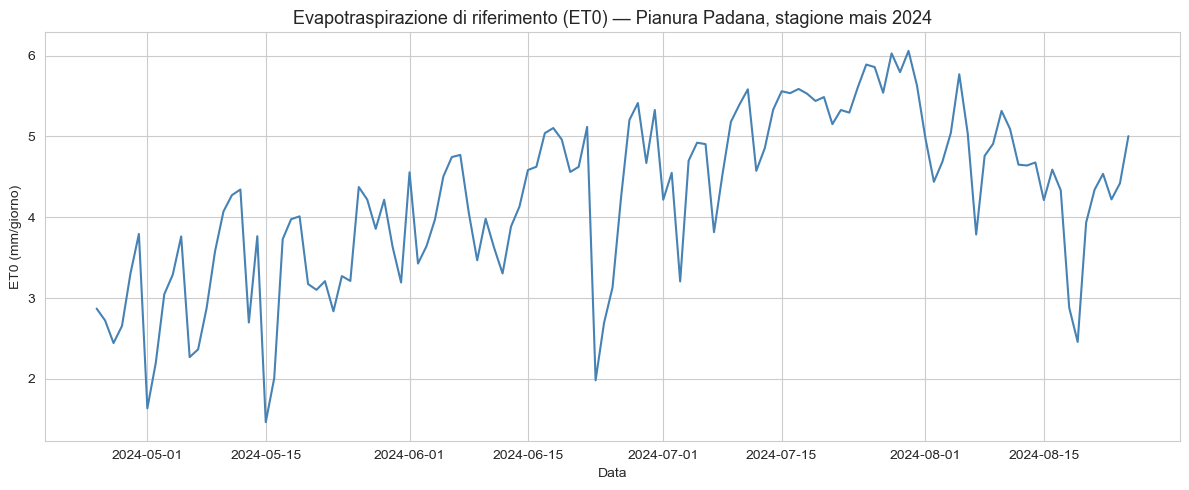

In [17]:
#Andamento stagionale
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(data=df_meteo, x=df_meteo.index, y="et0", ax=ax, color="steelblue", linewidth=1.5)

ax.set_title("Evapotraspirazione di riferimento (ET0) — Pianura Padana, stagione mais 2024", fontsize=13)
ax.set_xlabel("Data")
ax.set_ylabel("ET0 (mm/giorno)")

plt.tight_layout()
plt.show()

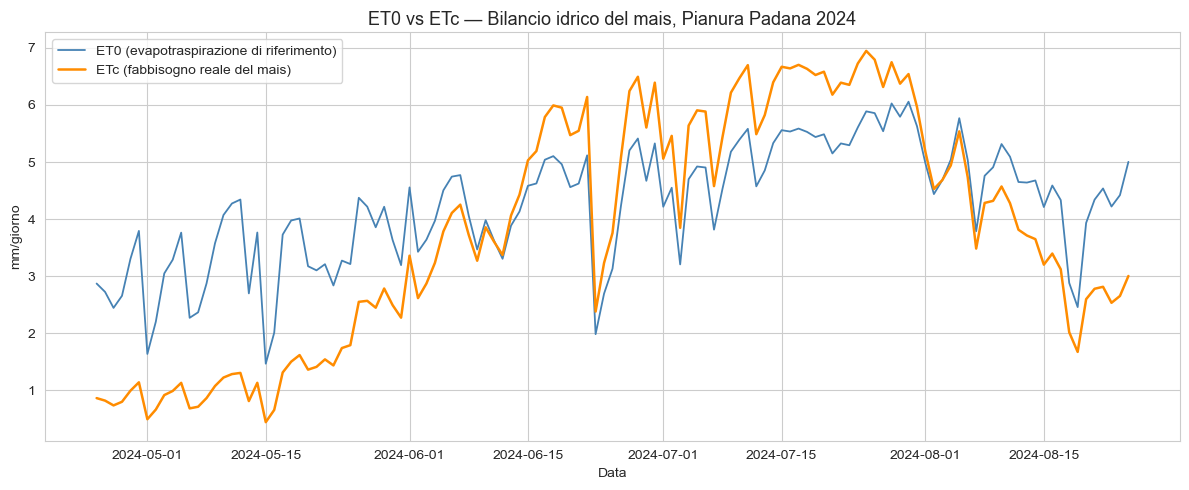

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(data=df_meteo, x=df_meteo.index, y="et0", ax=ax, 
             color="steelblue", linewidth=1.3, label="ET0 (evapotraspirazione di riferimento)")
sns.lineplot(data=df_meteo, x=df_meteo.index, y="etc", ax=ax, 
             color="darkorange", linewidth=1.8, label="ETc (fabbisogno reale del mais)")

ax.set_title("ET0 vs ETc — Bilancio idrico del mais, Pianura Padana 2024", fontsize=13)
ax.set_xlabel("Data")
ax.set_ylabel("mm/giorno")
ax.legend()

plt.tight_layout()
fig.savefig("../outputs/et0_vs_etc_plot.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
giorno_picco_et0 = df_meteo["et0"].idxmax()
giorno_picco_etc = df_meteo["etc"].idxmax()

print(f"Picco ET0: {giorno_picco_et0.date()} — {df_meteo.loc[giorno_picco_et0, 'et0']:.2f} mm/giorno")
print(f"Picco ETc: {giorno_picco_etc.date()} — {df_meteo.loc[giorno_picco_etc, 'etc']:.2f} mm/giorno (Kc={df_meteo.loc[giorno_picco_etc, 'kc']:.2f})")

Picco ET0: 2024-07-30 — 6.06 mm/giorno
Picco ETc: 2024-07-25 — 6.95 mm/giorno (Kc=1.18)


### Validazione dell'implementazione

Differenza media (mio − Open-Meteo): -0.10 mm/giorno
Errore medio assoluto (MAE):         0.12 mm/giorno
Differenza massima assoluta:         0.52 mm/giorno (2024-04-30)
Correlazione:                        0.993


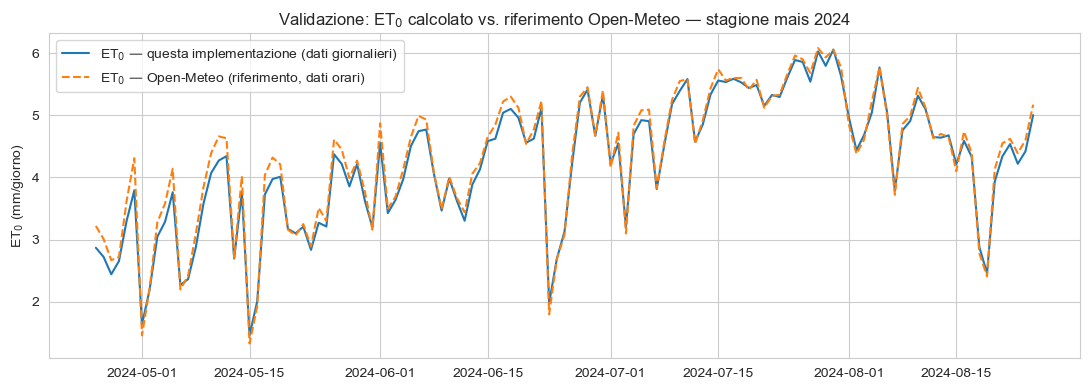

In [20]:
# Validazione: confronto con l'ET0 FAO-56 calcolato da Open-Meteo (da dati orari)
differenza = df_meteo["et0"] - df_meteo["et0_openmeteo"]

print(f"Differenza media (mio − Open-Meteo): {differenza.mean():+.2f} mm/giorno")
print(f"Errore medio assoluto (MAE):         {differenza.abs().mean():.2f} mm/giorno")
print(f"Differenza massima assoluta:         {differenza.abs().max():.2f} mm/giorno "
      f"({differenza.abs().idxmax().date()})")
print(f"Correlazione:                        {df_meteo['et0'].corr(df_meteo['et0_openmeteo']):.3f}")

fig_val, ax = plt.subplots(figsize=(11, 4))
sns.lineplot(x=df_meteo.index, y=df_meteo["et0"],
             label="ET$_0$ — questa implementazione (dati giornalieri)", ax=ax)
sns.lineplot(x=df_meteo.index, y=df_meteo["et0_openmeteo"],
             label="ET$_0$ — Open-Meteo (riferimento, dati orari)", ax=ax, linestyle="--")
ax.set_ylabel("ET$_0$ (mm/giorno)")
ax.set_xlabel("")
ax.set_title("Validazione: ET$_0$ calcolato vs. riferimento Open-Meteo — stagione mais 2024")
plt.tight_layout()
fig_val.savefig("../outputs/et0_validation_openmeteo.png", dpi=150, bbox_inches="tight")
plt.show()

Sull'intera stagione (123 giorni), l'ET0 calcolato in questo notebook si discosta in media di 
−0.10 mm/giorno dal riferimento Open-Meteo, con un errore medio assoluto di 0.12 mm/giorno e 
una correlazione di 0.993. Le piccole differenze sono coerenti con il diverso passo temporale 
dei due calcoli: questo notebook lavora su medie giornaliere, mentre Open-Meteo calcola l'ET0 
ora per ora. Anche la differenza massima (0.52 mm/giorno, il 30 aprile) resta contenuta.

In [21]:
# Salvataggio di dati e risultati (percorsi relativi alla cartella notebooks/)
COLONNE_METEO = [
    "temperature_2m_max", "temperature_2m_min", "temperature_2m_mean",
    "relative_humidity_2m_mean", "wind_speed_10m_mean",
    "shortwave_radiation_sum", "precipitation_sum",
]
df_meteo[COLONNE_METEO].to_csv("../data/weather_maize_po_valley_2024.csv")
df_meteo.to_csv("../outputs/water_balance_results_2024.csv")
print("Dati salvati in ../data, risultati in ../outputs")

Dati salvati in ../data, risultati in ../outputs


## Limitazioni note

- **Flusso di calore nel suolo (G = 0).** Su base giornaliera il flusso di calore nel suolo è 
  piccolo rispetto alla radiazione netta ed è approssimato a zero, come raccomandato da FAO-56. 
  L'approssimazione non vale per calcoli su base oraria o mensile, dove G va stimato 
  esplicitamente.
- **Radiazione netta ad onda lunga in cielo molto coperto.** L'equazione empirica FAO-56 per 
  Rnl è calibrata per condizioni da sereno a moderatamente nuvoloso. In 2 giorni su 123 
  produce valori leggermente negativi (minimo il 1° maggio, con rapporto Rs/Rso di 0.24): 
  i giorni sono identificati nel notebook e mantenuti senza correzione.
- **Kc tabellati.** Coefficienti colturali e durate delle fasi sono valori standard FAO-56 per 
  mais da granella, non calibrati sul campo né sull'ibrido specifico.
- **Un solo anno di dati.** Le date di picco (25 luglio per ETc, 30 luglio per ET0) descrivono 
  la stagione 2024; per generalizzarle servono più annate.
- **Calcolo su base giornaliera.** L'ET0 è calcolato da medie giornaliere di temperatura, 
  umidità e vento. Poiché l'equazione non è lineare in queste variabili, nelle giornate con 
  forte variabilità intra-giornaliera il calcolo orario previsto da FAO-56 è più accurato. 
  Il confronto con il riferimento orario di Open-Meteo quantifica l'effetto: errore medio 
  assoluto di 0.12 mm/giorno, con un massimo di 0.52 mm/giorno.

## Conclusioni
Il notebook fornisce un prototipo affidabile per stimare il fabbisogno idrico di una coltura 
di mais nella Pianura Padana tra aprile e agosto 2024, validato contro un riferimento 
indipendente (errore medio assoluto 0.12 mm/giorno). I principali limiti individuati sono 
l'approssimazione del flusso di calore nel suolo a zero, la disponibilità di un solo anno di 
dati, l'uso di Kc tabellati anziché calibrati in campo e il calcolo su base giornaliera. Per 
passare da prototipo a strumento operativo sono necessari dati multi-annuali, la calibrazione 
dei Kc tramite sensori di umidità del suolo e l'integrazione di previsioni meteo, per 
un'irrigazione predittiva anziché solo retrospettiva.